In [1]:
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import plotly.graph_objects as go
import pandas as pd
from scipy.optimize import curve_fit
from scipy.stats import f_oneway
import os
import time
from itertools import combinations

from dataeval.metrics.estimators import ber

from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.inspection import DecisionBoundaryDisplay
from sklearn.calibration import CalibratedClassifierCV
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import accuracy_score, balanced_accuracy_score, classification_report
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

from skl2onnx import to_onnx
from pickle import dump, load

import mlacca_functions as mlcf

# hide the "y_pred contains classes not in y_true" UserWarning from sklearn as it is expected when using different definitions
from warnings import filterwarnings
filterwarnings("ignore",module="sklearn",category=UserWarning)

In [2]:
df_path = 'mlacca_outputs\\csv_files\\new_vk_areas_df.csv'
weighted = True

In [3]:
df = pd.read_csv(df_path)

In [4]:
decision_boundaries_output_folder = 'mlacca_outputs\\plots\\decision_boundaries'
models_output_folder = 'mlacca_outputs\\models'
comparison_plots_output_folder = 'mlacca_outputs\\plots\\comparisons'

In [5]:
# Functions

def test_model_accuracy(model,X,y,repeats=50, classifier_name='[DEFAULT]', title=None,
                        xlabel=None,ylabel=None,colors_dict=None):

    accuracies = []

    for i in range(repeats):
        X_rdm_train, X_rdm_test, y_rdm_train, y_rdm_test, \
        weights_rdm_train, weights_rdm_test = mlcf.train_test(X, y,random_state=None)

        fitted_model = model.fit(X_rdm_train, y_rdm_train, sample_weight=weights_rdm_train if weighted else None)

        accuracies.append(balanced_accuracy_score(y_true = y_rdm_test,
                                                y_pred = fitted_model.predict(X_rdm_test),
                                                sample_weight=weights_rdm_test if weighted else None,
                                                ))

        if accuracies[i] == np.max(accuracies):
            max_model = fitted_model
            X_rdm_train_best = X_rdm_train
            y_rdm_train_best = y_rdm_train

    print(f'''Average accuracy of the {classifier_name} classifier trained on {len(X_rdm_train)} samples (run {repeats} times): {np.mean(accuracies)} +/- {np.std(accuracies)}
Max accuracy: {np.max(accuracies)}
Min accuracy: {np.min(accuracies)}
Random Accuracy: {1/len(np.unique(y_rdm_train))}''')

    if np.shape(X)[1] == 2:
        mlcf.draw_decision_boundary_plot(max_model,
                                    X_rdm_train_best,
                                    categories=np.unique(y_rdm_train_best),
                                    xlabel=xlabel,
                                    ylabel=ylabel,
                                    colors_dict=colors_dict,
                                    title=title
                                    )


def fitting_runtime(iterations:int,model,X,y,weights) -> float:

    times = []

    for i in range(iterations):
        start_time = time.time()
        fit = model.fit(X, y, sample_weight=weights)
        runtime = time.time() - start_time

        times.append(runtime)

    return sum(times)/iterations


def persist_model_onnx(clf, X, filepath):
    # https://scikit-learn.org/stable/model_persistence.html
    onx = to_onnx(clf, X[:1].astype(np.float32), target_opset=12)
    with open(filepath, "wb") as f:
        f.write(onx.SerializeToString())


def persist_model_pickle(clf, filepath):
    with open(filepath, "wb") as f:
        dump(clf, f, protocol=5)


def molecclass(df:pd.DataFrame,areas:dict,dims=['O/C','H/C','N/C']) ->  np.ndarray:

    assignments = ['unassigned'] * len(df)

    for i in df[dims].index:
        ratios = df[dims].loc[i]

        for a in areas:
            counter = 0

            for d in dims:
                if ratios[d] >= np.min(areas[a][d]) and ratios[d] <= np.max(areas[a][d]):
                    counter += 1
        
            if counter == len(dims):
                assignments[i] = a
                break
    
    assignments = np.array(assignments)
    assignments[np.where(assignments == 'peptide1')] = 'peptide'
    assignments[np.where(assignments == 'peptide2')] = 'peptide'

    return assignments


def create_3D_mesh(data, model, dims, number_of_points=50) -> pd.DataFrame:
    # https://www.kaggle.com/code/frankmollard/3d-decision-boundaries
    '''
    Create a 3D meshgrid for decision boundary visualization.
    '''
    data=data.copy()
    meshes_2d={}
    for i in range(len(dims)):
        meshes_2d.update({f"{dims[i]}": np.linspace(np.min(data[:,i]), np.max(data[:,i]), number_of_points)})

    # create meshgrid
    meshes_3d = np.meshgrid(*[x for x in meshes_2d.values()],
                            indexing='ij')

    stacked_mesh = np.vstack([x.ravel() for x in meshes_3d]).T  

    mesh_df = pd.DataFrame(stacked_mesh, columns=dims)

    preds = model.predict_proba(stacked_mesh)
    argmax = np.argmax(preds, axis=1)

    highest_probs = np.max(preds, axis=1)

    mesh_df['category'] = model.classes_[argmax]
    mesh_df['probability'] = highest_probs

    return mesh_df.sort_values(by=['category']).reset_index(drop=True)


def create_fig_for_3d_decision_boundary(mesh_df:pd.DataFrame, title:str=None, dims:list=None, alpha=.8, squareSize=10, colours=None) -> go.Figure:
    vizList = []
    for compound_class in mesh_df['category'].unique():

        i = mesh_df['category'] == compound_class

        compound_class_formatted = compound_class.capitalize().replace('Pah', 'PAH').replace('_',' ')

        globals()[f"D_{compound_class}"]=go.Scatter3d(

            x = mesh_df.loc[i, dims[0]],
            y = mesh_df.loc[i, dims[1]],
            z = mesh_df.loc[i, dims[2]],

            name = f"{compound_class_formatted}-like",

            hovertemplate = dims[0] + ': %{x} <br>' + \
                            dims[1] + ': %{y} <br>' + \
                            dims[2] + ': %{z} <br>',
                            # 'category: {0} <br>'.format(compound_class_formatted),

            mode='markers',
            marker=dict(
                size=squareSize,
                color=colours[compound_class],           
                opacity=alpha,#*mesh_df.loc[i, 'probability'].to_numpy(),
                symbol='square'
            )
        )

        vizList.append(globals()[f"D_{compound_class}"]) 

    fig = go.Figure(data=vizList,)

    camera = dict(
        up=dict(x=0, y=0, z=1),
        center=dict(x=0, y=0, z=0),
        eye=dict(x=-1, y=-1.75, z=1.5)
    )

    fig.update_layout(
        scene_camera=camera,
        autosize=True,
        template="plotly_white",
        scene={
            "xaxis_title":dims[0],
            "yaxis_title":dims[1],
            "zaxis_title":dims[2]
        },
        width=1800, height=900,
        showlegend=True,
        title = title if title else None
    )

    return fig

def DecisionBoundaryDisplay_3D(data, model, dims, alpha=.8, title=None, squareSize=10, number_of_points=50,
                               colours = mlcf.vk_region_colours,
                               savepath=None,show=True):
    # https://www.kaggle.com/code/frankmollard/3d-decision-boundaries
    '''
    Visualize 3D decision boundaries using Plotly.
    '''

    data = data.copy()

    mesh_df = create_3D_mesh(data=data, model=model, dims=dims, number_of_points=number_of_points)

    fig = create_fig_for_3d_decision_boundary(mesh_df=mesh_df, title=title, dims=dims, alpha=alpha, squareSize=squareSize, colours=colours)

    if show: fig.show()
    if savepath: fig.write_html(savepath)


def draw_violinplot(data_dict, ylabel, title=None, savepath=None, colours=[],hline=None,
                    xlabel_rotation=45,ha='right',figsize=(6.4, 4.8)):

    labels = list(data_dict.keys())
    data = list(data_dict.values())

    fig, ax = plt.subplots(figsize=figsize)

    parts = ax.violinplot(data,
                          showmeans=False, showmedians=False,
                          showextrema=False)

    if len(colours)>0:
        if len(colours)==1:
            colours = colours * len(labels)
        assert len(colours)==len(labels), "Number of colours must match number of violin plots"
        for pc,c in zip(parts['bodies'],colours):
            pc.set_facecolor(c)
            pc.set_edgecolor('black')
            pc.set_alpha(1)

    quartile1, medians, quartile3 = np.percentile(np.array(data), [25, 50, 75], axis=1)

    inds = np.arange(1, len(medians) + 1)
    ax.scatter(inds, medians, marker='o', color='white', s=30, zorder=3, edgecolors='k')
    ax.vlines(inds, quartile1, quartile3, color='k', linestyle='-', lw=5)

    ax.set_ylabel(ylabel, fontsize=12)
    ax.set_xticks(np.arange(1,len(labels)+1), labels, rotation=xlabel_rotation, ha=ha, fontsize=12)

    if hline:
        if type(hline) in [list, tuple]:
            for hl in hline:
                ax.axhline(y=hl, color='r', linestyle='--', lw=1)
        else:
            ax.axhline(y=hline, color='r', linestyle='--', lw=1)

    if title: ax.set_title(title, fontsize=14)
    if savepath: fig.savefig(savepath, dpi=600, facecolor='#fff', bbox_inches='tight')

    return fig, ax


def correlation_matrix(data_dict, threshold=0.05, savepath=None, title=None,
                       colours=['tab:orange','tab:blue']):

    # first colour for p <= threshold (significant difference),
    # second for p > threshold (not significant difference)

    labels = list(data_dict.keys())

    p_dict = {}
    for comb in list(combinations(labels,2)):
        p_dict[f'{comb[0]},{comb[1]}'] = f_oneway(*[data_dict[comb[0]],data_dict[comb[1]]],nan_policy='omit')[1]

    # draw a binary correlation matrix plot of the p values and colour only the values < 0.05
    p_matrix = pd.DataFrame(np.ones((len(labels),len(labels))), index=labels, columns=labels)
    p_matrix[p_matrix == 1] = np.nan
    for comb in list(combinations(labels,2)):
        p_value = p_dict[f'{comb[0]},{comb[1]}']
        p_matrix.loc[comb[0], comb[1]] = np.nan
        p_matrix.loc[comb[1], comb[0]] = p_value

    p_matrix[(p_matrix > threshold)&(p_matrix.notna())] = 1
    p_matrix[(p_matrix <= threshold)&(p_matrix.notna())] = 0

    fig, ax = plt.subplots()

    cmap = mpl.colors.ListedColormap(colours)

    cax = ax.matshow(p_matrix, cmap=cmap)

    for label, colour in zip([f'$p\\leq{threshold}$', f'$p>{threshold}$'], colours):
        ax.scatter([], [], c=colour, label=label,marker='s',s=100)

    ax.legend(framealpha=1,bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0,fontsize=12)

    ax.set_xticks(np.arange(len(labels)-1), labels[:-1], rotation=45,horizontalalignment='right')
    ax.set_yticks(np.arange(1,len(labels)), labels[1:])
    ax.xaxis.set_ticks_position('bottom')
    ax.set_xlim(-0.5, len(labels)-1.5)
    ax.set_ylim(len(labels)-0.5, 0.5)

    if title: ax.set_title(title, fontsize=14)
    if savepath: fig.savefig(savepath, dpi=600, facecolor='#fff', bbox_inches='tight')

    return fig, ax

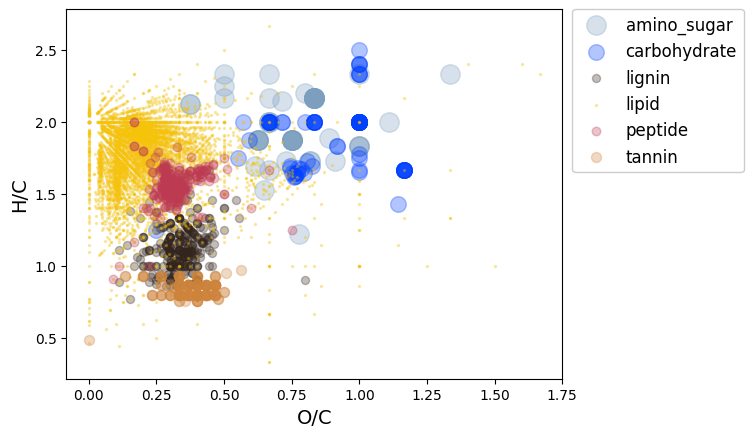

In [6]:
#plot the Van Krevelen diagram
fig, ax = plt.subplots()

for category in df['category'].unique():
    subset = df[df['category'] == category]
    ax.scatter(subset['O/C'], subset['H/C'], label=category, c = mlcf.vk_region_colours[category],
               alpha=0.3, s=1e4/len(df[df['category'] == category])) # the size of the points is inversely proportional to the number of points in that category

ax.set_xlabel('O/C', fontsize=14)
ax.set_ylabel('H/C', fontsize=14)
ax.legend(framealpha=1,bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0,fontsize=12)

In [7]:
columns_2d = ['O/C','H/C']#, 'N/C', 'S/C', 'P/C']
X_2d = df[columns_2d].to_numpy()

columns_3d = ['O/C','H/C','N/C']
X_3d = df[columns_3d].to_numpy()

y = df['category'].to_numpy()
weights = df['weights'].to_numpy() if weighted else None

multiclass_colors=[mlcf.vk_region_colours[cat] for cat in np.unique(y)]

In [8]:
# Run this cell twice as the first run sometimes gives an error in ber calculation but the second run works.
# Mystery for the ages . . .

for i in range(2):
    while True:
        try:
            bayes_error_rate_2d = ber(X_2d, y, method="MST")
            max_acc_2d = 1-bayes_error_rate_2d.ber

            bayes_error_rate_3d = ber(X_3d, y, method="MST")
            max_acc_3d = 1-bayes_error_rate_3d.ber

        except TypeError:
            continue
        break

c:\Users\s2017658\.conda\envs\mlacca_env\Lib\site-packages\dataeval\core\_mst.py:235: RuntimeWarning: Exhausted k-nearest neighbors (k=14) before finding connected spanning tree. Consider increasing k parameter. Falling back to inter-cluster connection heuristics.
  warnings.warn(
c:\Users\s2017658\.conda\envs\mlacca_env\Lib\site-packages\dataeval\core\_mst.py:235: RuntimeWarning: Exhausted k-nearest neighbors (k=14) before finding connected spanning tree. Consider increasing k parameter. Falling back to inter-cluster connection heuristics.
  warnings.warn(
c:\Users\s2017658\.conda\envs\mlacca_env\Lib\site-packages\dataeval\core\_mst.py:235: RuntimeWarning: Exhausted k-nearest neighbors (k=14) before finding connected spanning tree. Consider increasing k parameter. Falling back to inter-cluster connection heuristics.
  warnings.warn(
c:\Users\s2017658\.conda\envs\mlacca_env\Lib\site-packages\dataeval\core\_mst.py:235: RuntimeWarning: Exhausted k-nearest neighbors (k=14) before finding 

In [9]:
# Train 2D models on the entire dataset
knn_2d = mlcf.knn_pipeline(mlcf.knn_param_2d).fit(X_2d, y)
gnb_2d = CalibratedClassifierCV(GaussianNB()).fit(X_2d, y, sample_weight=weights if weighted else None)
svm_poly_2d = CalibratedClassifierCV(SVC(kernel="poly",**mlcf.svm_poly_param_2d,probability=True)).fit(X_2d, y, sample_weight=weights if weighted else None)
svm_rbf_2d = CalibratedClassifierCV(SVC(kernel="rbf",**mlcf.svm_rbf_param_2d,probability=True)).fit(X_2d, y, sample_weight=weights if weighted else None)

In [10]:
# Train 3D models on the entire dataset
knn_3d = mlcf.knn_pipeline(mlcf.knn_param_3d).fit(X_3d, y)
gnb_3d = CalibratedClassifierCV(GaussianNB()).fit(X_3d, y, sample_weight=weights if weighted else None)
svm_poly_3d = CalibratedClassifierCV(SVC(kernel="poly",**mlcf.svm_poly_param_3d,probability=True)).fit(X_3d, y, sample_weight=weights if weighted else None)
svm_rbf_3d = CalibratedClassifierCV(SVC(kernel="rbf",**mlcf.svm_rbf_param_3d,probability=True)).fit(X_3d, y, sample_weight=weights if weighted else None)

In [11]:
# save the models
persist_model_pickle(knn_3d,f"{models_output_folder}\\knn.pkl")
persist_model_pickle(gnb_3d,f"{models_output_folder}\\gnb.pkl")
persist_model_pickle(svm_poly_3d,f"{models_output_folder}\\svm_poly.pkl")
persist_model_pickle(svm_rbf_3d,f"{models_output_folder}\\svm_rbf.pkl")

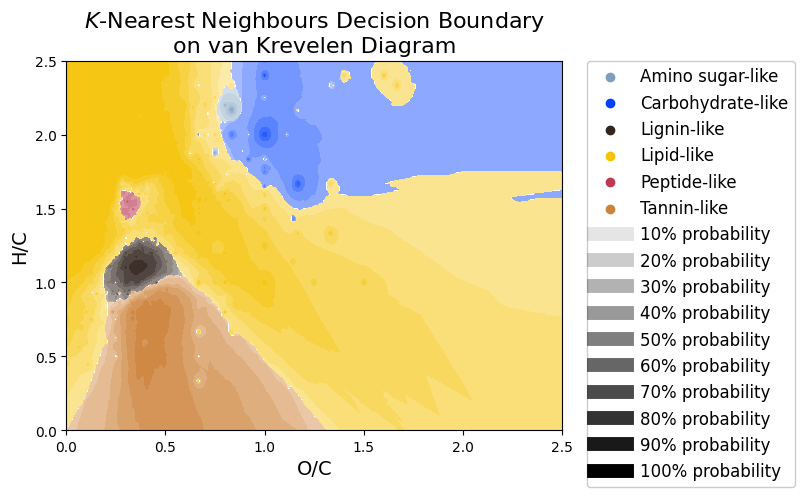

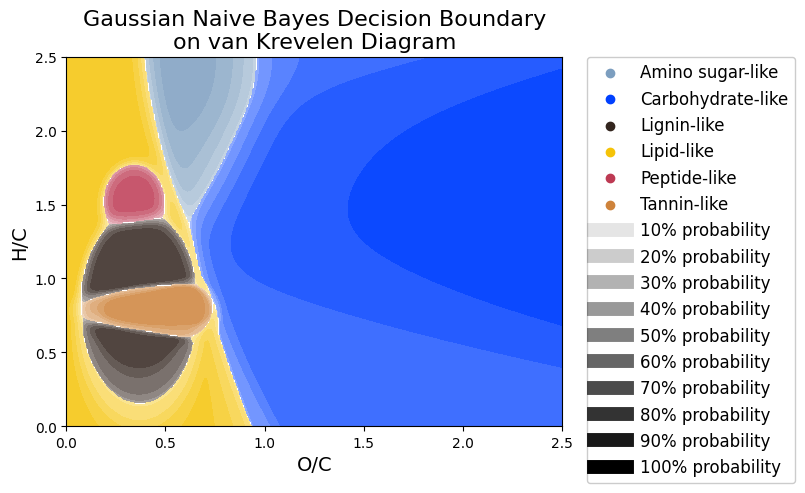

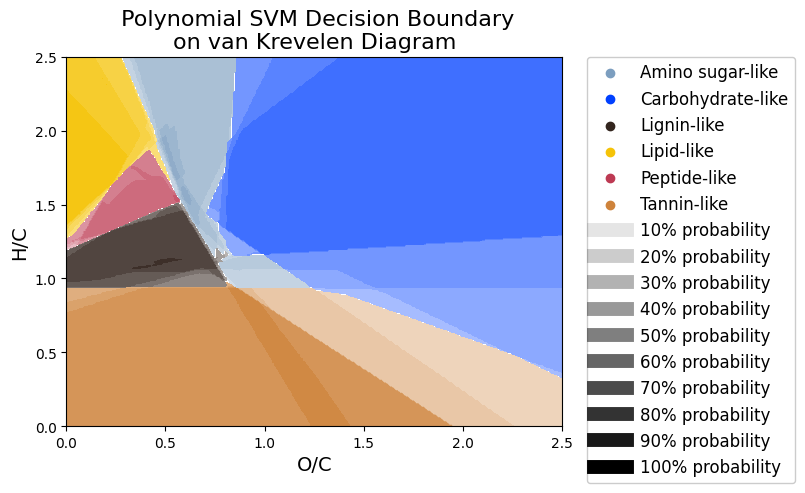

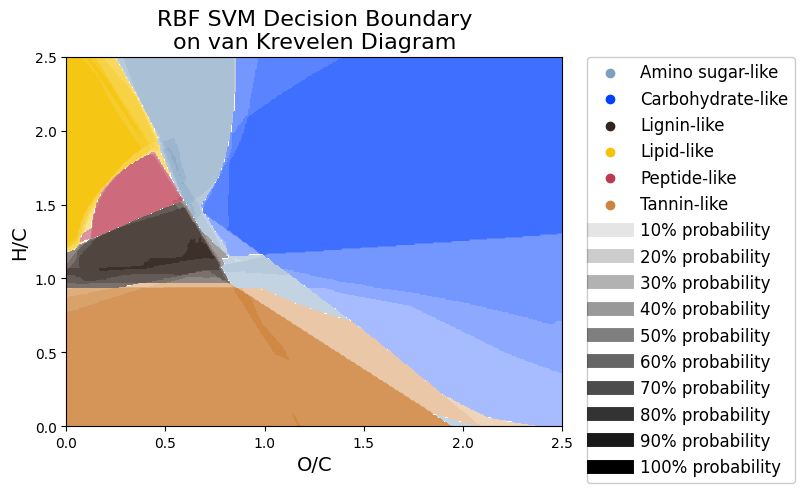

In [12]:
# plot decision boundaries for 2D models
mlcf.draw_decision_boundary_plot(knn_2d,
                                X_2d,
                                categories=np.unique(y),
                                xlabel=columns_2d[0],
                                ylabel=columns_2d[1],
                                title='$K$-Nearest Neighbours Decision Boundary\non van Krevelen Diagram',
                                savepath=f'{decision_boundaries_output_folder}\\knn_vk_decision_boundary.svg',
                                colors_dict=mlcf.vk_region_colours
                                )

mlcf.draw_decision_boundary_plot(gnb_2d,
                                X_2d,
                                categories=np.unique(y),
                                xlabel=columns_2d[0],
                                ylabel=columns_2d[1],
                                title='Gaussian Naive Bayes Decision Boundary\non van Krevelen Diagram',
                                savepath=f'{decision_boundaries_output_folder}\\gnb_vk_decision_boundary.svg',
                                colors_dict=mlcf.vk_region_colours
                                )

mlcf.draw_decision_boundary_plot(svm_poly_2d,
                                X_2d,
                                categories=np.unique(y),
                                xlabel=columns_2d[0],
                                ylabel=columns_2d[1],
                                title=f' Polynomial SVM Decision Boundary\non van Krevelen Diagram',
                                savepath=f'{decision_boundaries_output_folder}\\svm_poly_vk_decision_boundary.svg',
                                colors_dict=mlcf.vk_region_colours
                                )

mlcf.draw_decision_boundary_plot(svm_rbf_2d,
                                X_2d,
                                categories=np.unique(y),
                                xlabel=columns_2d[0],
                                ylabel=columns_2d[1],
                                title=f'RBF SVM Decision Boundary\non van Krevelen Diagram',
                                savepath=f'{decision_boundaries_output_folder}\\svm_rbf_vk_decision_boundary.svg',
                                colors_dict=mlcf.vk_region_colours
                                )

In [13]:
# plot decision boundaries for 3D models

DecisionBoundaryDisplay_3D(X_3d, knn_3d, dims=columns_3d,
                           title="K-Nearest Neighbours 3D Boundary",
                           savepath=f'{decision_boundaries_output_folder}\\knn_3d_vk_decision_boundary.html',
                           show=False)
DecisionBoundaryDisplay_3D(X_3d, gnb_3d, dims=columns_3d,
                           title="Naive Bayes Decision 3D Boundary",
                           savepath=f'{decision_boundaries_output_folder}\\gnb_3d_vk_decision_boundary.html',
                           show=False)
DecisionBoundaryDisplay_3D(X_3d, svm_poly_3d, dims=columns_3d,
                           title="Polynomial SVM Decision 3D Boundary",
                           savepath=f'{decision_boundaries_output_folder}\\svm_poly_3d_vk_decision_boundary.html',
                           show=False)
DecisionBoundaryDisplay_3D(X_3d, svm_rbf_3d, dims=columns_3d,
                           title="RBF SVM Decision 3D Boundary",
                           savepath=f'{decision_boundaries_output_folder}\\svm_rbf_3d_vk_decision_boundary.html',
                           show=False)

In [14]:
# comparison of these models with literature models

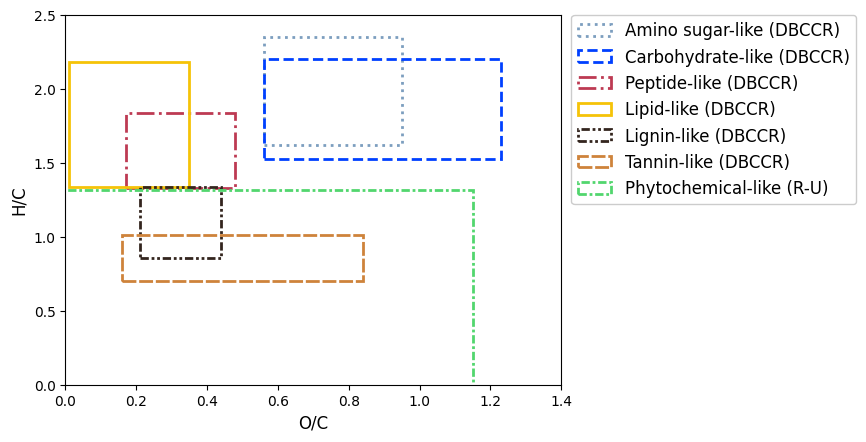

In [15]:
# show overlap of phytochemical and lignin/tannin definitions used

def rectangle(ax,p1,p2,**kwargs):
    h = p2[1]-p2[0]
    w = p1[1]-p1[0]

    facecolor = kwargs.get('facecolor',None)
    edgecolor = kwargs.get('edgecolor',None)
    alpha = kwargs.get('alpha',None)
    label = kwargs.get('label',None)
    lw = kwargs.get('lw',None)
    ls = kwargs.get('ls',None)

    rect=plt.Rectangle((p1[0],p2[0]),w,h,facecolor=facecolor, alpha=alpha, edgecolor=edgecolor,label=label,lw=lw,ls=ls)
    ax.add_patch(rect)

fig, ax = plt.subplots()

areas_compare = {x:mlcf.laszakovits_mackay_areas[x] for x in mlcf.laszakovits_mackay_areas}
areas_compare['phytochemical'] = mlcf.rivasubach_areas['phytochemical']

ls_dict ={
    'lipid': 'solid', 
    'peptide': 'dashdot',

    'carbohydrate': 'dashed',
    'amino_sugar': 'dotted', 
    
    'lignin': (0, (3, 1, 1, 1, 1, 1)), 
    'tannin': (0, (5, 1)),
    'phytochemical': (0, (3, 1, 1, 1))
}

for a in areas_compare:
    # i = keys.index(a)
    label = f'{a.capitalize().replace('_',' ')}-like'
    
    label += ' (DBCCR)' if a in mlcf.laszakovits_mackay_areas else ' (R-U)'

    rectangle(ax,areas_compare[a]['O/C'],areas_compare[a]['H/C'],
              facecolor='none',edgecolor=mlcf.vk_region_colours[a],label=label,ls=ls_dict[a],lw=2)#,ls='--')

ax.legend(framealpha=1,bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0,fontsize=12)
ax.set_xlim(0,1.4)
ax.set_ylim(0,2.5)
ax.set_xlabel('O/C',fontsize=12)
ax.set_ylabel('H/C',fontsize=12)
fig.savefig('mlacca_outputs\\plots\\van_krevelens\\l&m_and_phytochemical.png',dpi=600, facecolor = '#fff', bbox_inches='tight')

In [16]:
rivas_ubach_adj_cat = df['category'].copy().to_numpy()
rivas_ubach_adj_cat[np.where(rivas_ubach_adj_cat == 'tannin')] = 'phytochemical'
rivas_ubach_adj_cat[np.where(rivas_ubach_adj_cat == 'lignin')] = 'phytochemical'

rivas_ubach_class_weights = compute_class_weight('balanced', classes=np.unique(rivas_ubach_adj_cat), y=rivas_ubach_adj_cat)
rivas_ubach_class_weights_dict = {cls: weight for cls, weight in zip(np.unique(rivas_ubach_adj_cat), rivas_ubach_class_weights)}
rivas_ubach_weights = [rivas_ubach_class_weights_dict[cat] for cat in rivas_ubach_adj_cat]

In [17]:
# test the model accuracies using the same slices of the overall dataset and plot boxplots and do ANOVA on the results

clf_models = {
    'GNB (W)': CalibratedClassifierCV(GaussianNB()),
    'SVM (poly) (W)': CalibratedClassifierCV(SVC(kernel="poly", **mlcf.svm_poly_param_3d)),
    'SVM (RBF) (W)': CalibratedClassifierCV(SVC(kernel="rbf", **mlcf.svm_rbf_param_3d)),
}

clf_models_unweighted = {x.replace('(W)','(U)'):clf_models[x] for x in clf_models}
clf_models_unweighted['KNN'] = mlcf.knn_pipeline(mlcf.knn_param_3d)

lit_models = {
    'DBCCR': mlcf.laszakovits_mackay_areas,
    'Adjusted MSCC': mlcf.ru_lm_areas,
}

phyto_clf_models = {f'{x} (R-U)' : clf_models[x] for x in clf_models}

phyto_clf_models_unweighted = {f'{x} (R-U)' : clf_models_unweighted[x] for x in clf_models_unweighted}

phyto_lit_model = {'MSCC': mlcf.rivasubach_areas,}

models_list = list(lit_models.keys()) + list(clf_models_unweighted.keys()) + list(clf_models.keys()) +\
              list(phyto_lit_model.keys()) + list(phyto_clf_models_unweighted.keys()) + list(phyto_clf_models.keys())

In [18]:
accuracies_dict = {name: [] for name in models_list}
balanced_accuracies_dict = {name: [] for name in models_list}
zero_rule_acc = []

repeats = 40

for n in range(repeats):
    print(f'Accuracy test iteration {n+1} of {repeats}')

    X_rdm_train, X_rdm_test, y_rdm_train, y_rdm_test, \
    weights_rdm_train, weights_rdm_test = mlcf.train_test(X_3d, y,random_state=None)

    zero_rule_class = np.unique(y_rdm_test)[np.argmax([len(np.where(y_rdm_test==cat)[0]) for cat in np.unique(y_rdm_test)])]
    zero_rule_acc.append(accuracy_score(y_true=y_rdm_test,
                                        y_pred=[zero_rule_class]*len(y_rdm_test),
                                        normalize=True))

    for model in clf_models:
        print(f'{n+1}/{repeats}\tTesting model: {model}')

        clf = clf_models[model].fit(X_rdm_train, y_rdm_train, sample_weight=weights_rdm_train if weighted else None)
        y_pred = clf.predict(X_rdm_test)

        acc = accuracy_score(y_true=y_rdm_test,
                             y_pred=y_pred,
                             normalize=True)
        accuracies_dict[model].append(acc)

        balanced_acc = balanced_accuracy_score(y_true=y_rdm_test,
                                               y_pred=y_pred,
                                               sample_weight=weights_rdm_test if weighted else None)
        balanced_accuracies_dict[model].append(balanced_acc)

        print(f'\t\taccuracy: {acc}, balanced accuracy: {balanced_acc}')

    
    for model in clf_models_unweighted:
        print(f'{n+1}/{repeats}\tTesting model: {model}')

        clf = clf_models_unweighted[model].fit(X_rdm_train, y_rdm_train)
        y_pred = clf.predict(X_rdm_test)

        acc = accuracy_score(y_true=y_rdm_test,
                             y_pred=y_pred,
                             normalize=True)
        accuracies_dict[model].append(acc)

        balanced_acc = balanced_accuracy_score(y_true=y_rdm_test,
                                               y_pred=y_pred,
                                               sample_weight=weights_rdm_test if weighted else None)
        balanced_accuracies_dict[model].append(balanced_acc)

        print(f'\t\taccuracy: {acc}, balanced accuracy: {balanced_acc}')


    for model in lit_models:
        print(f'{n+1}/{repeats}\tTesting model: {model}')

        cols = columns_3d if 'DBCCR' not in model else columns_2d

        y_pred = molecclass(pd.DataFrame(X_rdm_test, columns=columns_3d), areas=lit_models[model], dims=cols)

        acc = accuracy_score(y_true=y_rdm_test,
                             y_pred=y_pred,
                             normalize=True)
        accuracies_dict[model].append(acc)
        
        balanced_acc = balanced_accuracy_score(y_true=y_rdm_test,
                                               y_pred=y_pred,
                                               sample_weight=weights_rdm_test if weighted else None)
        balanced_accuracies_dict[model].append(balanced_acc)

        print(f'\t\taccuracy: {acc}, balanced accuracy: {balanced_acc}')


    # phytochemical replaced by lignin and tannin definitions from Laszakovits and MacKay 2022
    X_rdm_train_phyto, X_rdm_test_phyto, y_rdm_train_phyto, y_rdm_test_phyto, \
    weights_rdm_train_phyto, weights_rdm_test_phyto = mlcf.train_test(X_3d, rivas_ubach_adj_cat,random_state=None)

    for model in phyto_clf_models:
        print(f'{n+1}/{repeats}\tTesting model: {model}')

        clf = phyto_clf_models[model].fit(X_rdm_train_phyto, y_rdm_train_phyto, sample_weight=weights_rdm_train_phyto if weighted else None)
        y_pred = clf.predict(X_rdm_test_phyto)

        acc = accuracy_score(y_true=y_rdm_test_phyto,
                             y_pred=y_pred,
                             normalize=True)
        accuracies_dict[model].append(acc)

        balanced_acc = balanced_accuracy_score(y_true=y_rdm_test_phyto,
                                               y_pred=y_pred,
                                               sample_weight=weights_rdm_test_phyto if weighted else None)
        
        balanced_accuracies_dict[model].append(balanced_acc)

        print(f'\t\taccuracy: {acc}, balanced accuracy: {balanced_acc}')

    
    for model in phyto_clf_models_unweighted:
        print(f'{n+1}/{repeats}\tTesting model: {model}')
    
        clf = phyto_clf_models_unweighted[model].fit(X_rdm_train_phyto, y_rdm_train_phyto)
        y_pred = clf.predict(X_rdm_test_phyto)

        acc = accuracy_score(y_true=y_rdm_test_phyto,
                             y_pred=y_pred,
                             normalize=True)
        accuracies_dict[model].append(acc)

        balanced_acc = balanced_accuracy_score(y_true=y_rdm_test_phyto,
                                               y_pred=y_pred,
                                               sample_weight=weights_rdm_test_phyto if weighted else None)
        
        balanced_accuracies_dict[model].append(balanced_acc)

        print(f'\t\taccuracy: {acc}, balanced accuracy: {balanced_acc}')


    for model in phyto_lit_model:
        print(f'{n+1}/{repeats}\tTesting model: {model}')

        y_pred = molecclass(pd.DataFrame(X_rdm_test_phyto, columns=columns_3d), areas=phyto_lit_model[model], dims=columns_3d)
        
        acc = accuracy_score(y_true=y_rdm_test_phyto,
                             y_pred=y_pred,
                             normalize=True)
        accuracies_dict[model].append(acc)

        balanced_acc = balanced_accuracy_score(y_true=y_rdm_test_phyto,
                                               y_pred=y_pred,
                                               sample_weight=weights_rdm_test_phyto if weighted else None)
        
        balanced_accuracies_dict[model].append(balanced_acc)

        print(f'\t\taccuracy: {acc}, balanced accuracy: {balanced_acc}')


Accuracy test iteration 1 of 40
1/40	Testing model: GNB (W)
		accuracy: 0.7481234361968306, balanced accuracy: 0.8952633454008699
1/40	Testing model: SVM (poly) (W)
		accuracy: 0.8757297748123436, balanced accuracy: 0.954159208324238
1/40	Testing model: SVM (RBF) (W)
		accuracy: 0.8899082568807339, balanced accuracy: 0.9594242263593934
1/40	Testing model: GNB (U)
		accuracy: 0.9190992493744787, balanced accuracy: 0.5426185798484423
1/40	Testing model: SVM (poly) (U)
		accuracy: 0.9382819015846539, balanced accuracy: 0.678719244082702
1/40	Testing model: SVM (RBF) (U)
		accuracy: 0.9291075896580484, balanced accuracy: 0.6275222710782632
1/40	Testing model: KNN
		accuracy: 0.9624687239366139, balanced accuracy: 0.950374424382283
1/40	Testing model: DBCCR
		accuracy: 0.5929941618015012, balanced accuracy: 0.6594692173867023
1/40	Testing model: Adjusted MSCC
		accuracy: 0.8773978315262719, balanced accuracy: 0.7670709149687539
1/40	Testing model: GNB (W) (R-U)
		accuracy: 0.778982485404503

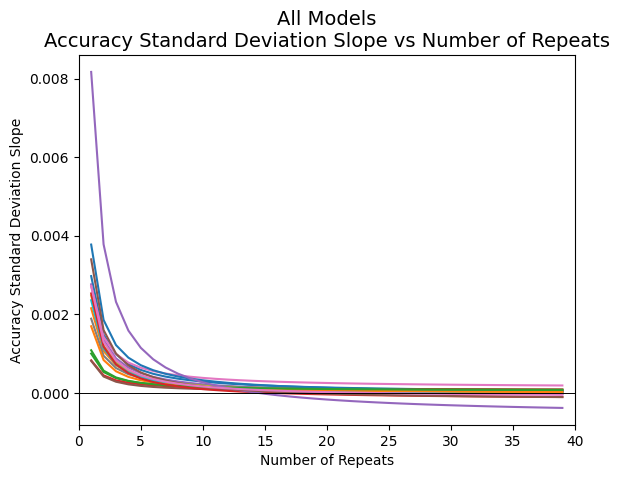

In [19]:
# Plot the derivative of std vs number of repeats.
# Only save the plot of this cell after running the accuracy tests cell for a large number of repeats (e.g. 200) to see where the std stabilizes.
# This is to help decide on a reasonable number of repeats for future tests.

SAVE = False

def fitting_func(x, a, b, c):
    return a * (b * x)**(-1) + c

curves_list = []

for model in models_list:
    fig, ax = plt.subplots()

    n_of_times = range(1,len(accuracies_dict[model])+1)

    step_wise_stds = [np.std(accuracies_dict[model][:i]) for i in n_of_times]

    y_axis = np.diff(step_wise_stds)/np.diff(n_of_times)

    ax.scatter(n_of_times[:-1], y_axis,marker='.', alpha=0.7)

    popt, pcov = curve_fit(fitting_func, n_of_times[:-1], y_axis)
    curves_list.append(fitting_func(np.array(n_of_times[:-1]), *popt))
    ax.plot(n_of_times[:-1], curves_list[-1], 'r--', label=f'${popt[0]}*\\frac{{1}}{{{popt[1]}}}*x + {popt[2]}$')

    ax.set_title(f'{model}\nAccuracy Standard Deviation Slope vs Number of Repeats', fontsize=14)
    ax.set_xlabel('Number of Repeats')
    ax.set_ylabel('Accuracy Standard Deviation Slope')
    ax.set_xlim(0, len(accuracies_dict[model]))

    ax.axhline(0,lw=.7,c='k')

    if SAVE:
        fig.savefig(f'mlacca_outputs\\plots\\comparisons\\accuracy_std_vs_repeats\\accuracy_std_slope_vs_repeats_{model.replace(' ','_')}.png', dpi=600, facecolor='#fff', bbox_inches='tight')

    plt.close()

fig, ax = plt.subplots()
for curve in curves_list:
    ax.plot(range(1,len(accuracies_dict[model])), curve)
ax.set_title(f'All Models\nAccuracy Standard Deviation Slope vs Number of Repeats', fontsize=14)
ax.set_xlabel('Number of Repeats')
ax.set_ylabel('Accuracy Standard Deviation Slope')
ax.set_xlim(0, len(accuracies_dict[model]))
ax.axhline(0,lw=.7,c='k')
if SAVE:
    fig.savefig(f'mlacca_outputs\\plots\\comparisons\\accuracy_std_vs_repeats\\accuracy_std_slope_vs_repeats_all_models.png', dpi=600, facecolor='#fff', bbox_inches='tight')

In [20]:
# adjust accuracies_dict values by the chance of random guessing
chance_balanced_accuracies_dict = {}

for key in balanced_accuracies_dict:
    number_of_categories = len(np.unique(y)) if key not in list(phyto_lit_model.keys()) + list(phyto_clf_models.keys()) else len(np.unique(rivas_ubach_adj_cat))

    chance = 1 / number_of_categories

    chance_balanced_accuracies_dict[key] = [(acc-chance)/(1 - chance) for acc in balanced_accuracies_dict[key] ]

In [21]:
comparison_df = pd.DataFrame({
    'model':[model.replace('$', '').replace('\\', '') for model in models_list],
    'mean_accuracy':[np.mean(accuracies_dict[model]) for model in models_list],
    'std_accuracy':[np.std(accuracies_dict[model]) for model in models_list],
    'median_accuracy':[np.median(accuracies_dict[model]) for model in models_list],
    'mean_balanced_accuracy':[np.mean(balanced_accuracies_dict[model]) for model in models_list],
    'std_balanced_accuracy':[np.std(balanced_accuracies_dict[model]) for model in models_list],
    'median_balanced_accuracy':[np.median(balanced_accuracies_dict[model]) for model in models_list],
    'mean_chance_balanced_accuracy':[np.mean(chance_balanced_accuracies_dict[model]) for model in models_list],
    'std_chance_balanced_accuracy':[np.std(chance_balanced_accuracies_dict[model]) for model in models_list],
    'median_chance_balanced_accuracy':[np.median(chance_balanced_accuracies_dict[model]) for model in models_list],
})

comparison_df.to_csv('mlacca_outputs\\csv_files\\model_performance_comparison.csv', index=False)

In [22]:
# comparison_df

In [23]:
def set_y_ticks(data_dict,ax,major_ticks_interval=0.1,minor_ticks_interval=0.05,rounding=2):
    ylim = (np.round(np.floor(10**rounding*np.min(list(data_dict.values())))/10**rounding,rounding)-10**-rounding, 1)
    ax.set_ylim(ylim)
    
    ax.set_yticks(np.arange(np.round(np.floor(1e2*ylim[0])/1e2,1),ylim[1]+0.01, major_ticks_interval))

    ax.tick_params(axis='y', which='minor')
    ax.yaxis.set_minor_locator(mpl.ticker.MultipleLocator(minor_ticks_interval))

In [24]:
# boxplot_colors = []
boxplot_colors_dict = {'Literature Models':'moccasin',
                       'Weighted Supervised\nClassifier Models':'skyblue',
                       'Unweighted Supervised\nClassifier Models':'lightcoral'}
zero_rule_colour = 'grey'

def model_colour(model):
    if model in clf_models or model in phyto_clf_models:
        return boxplot_colors_dict['Weighted Supervised\nClassifier Models']
    elif model in lit_models or model in phyto_lit_model:
        return boxplot_colors_dict['Literature Models']
    elif model in clf_models_unweighted or model in phyto_clf_models_unweighted:
        return boxplot_colors_dict['Unweighted Supervised\nClassifier Models']
    else: return zero_rule_colour

plot_type = {'boxplot':mlcf.draw_boxplot,
             'violinplot':draw_violinplot}

data_dict = {'raw':accuracies_dict,
             'balanced':balanced_accuracies_dict,
             'chance':chance_balanced_accuracies_dict}

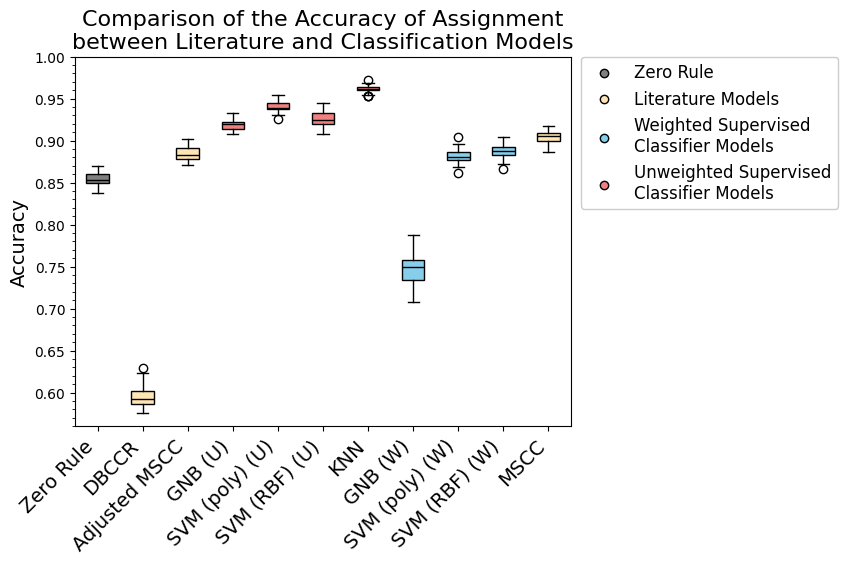

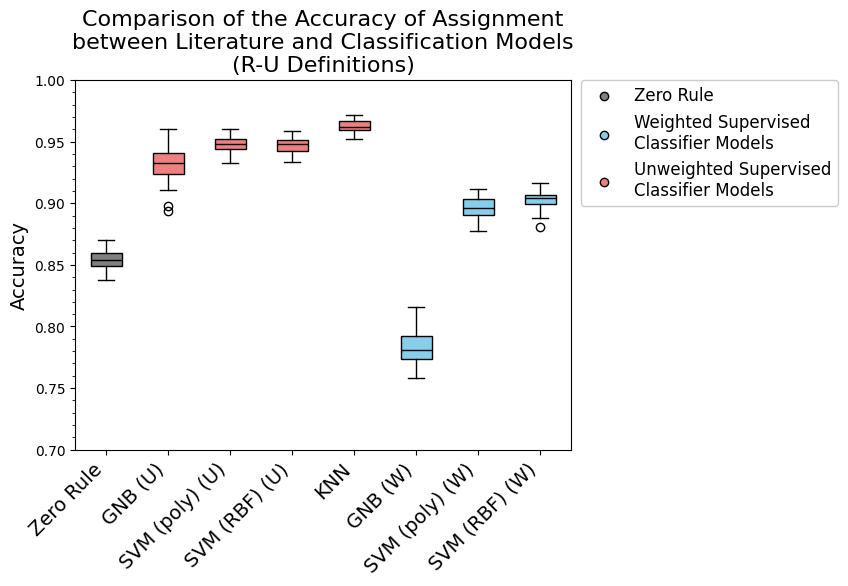

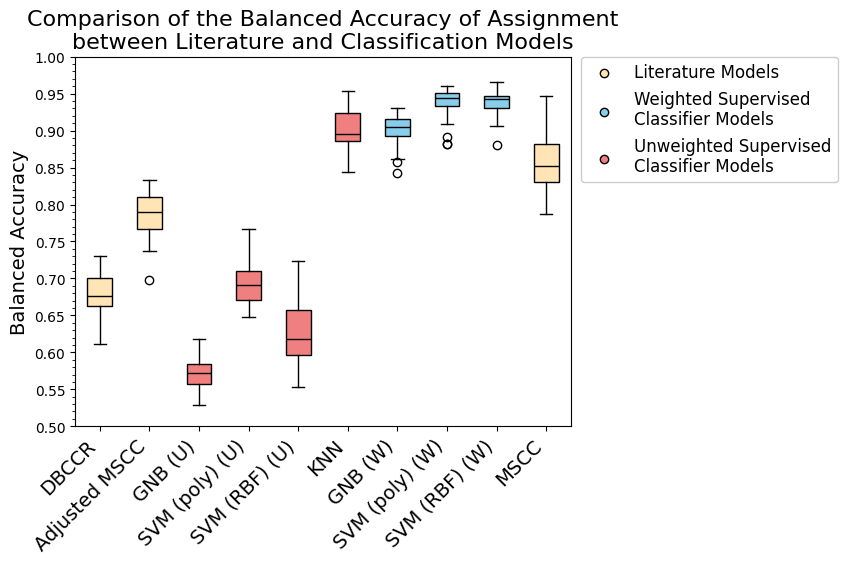

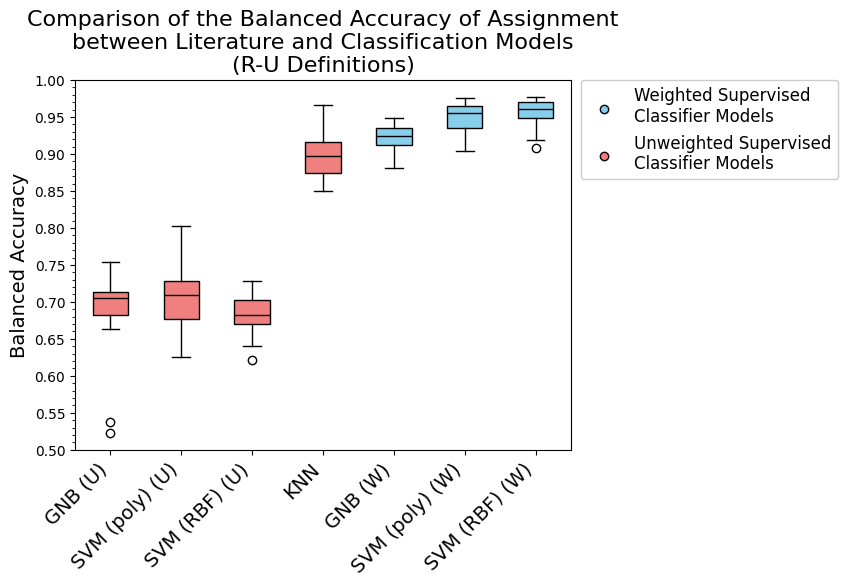

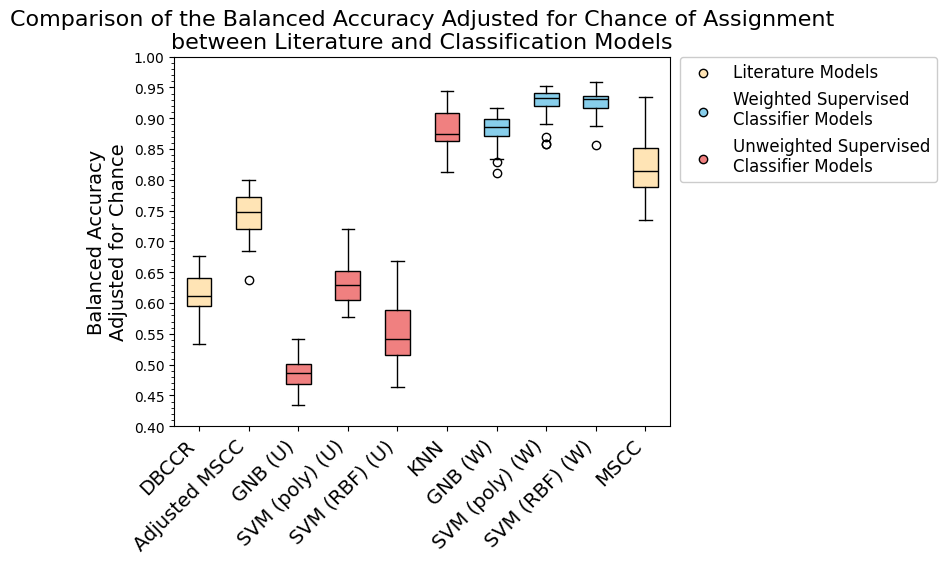

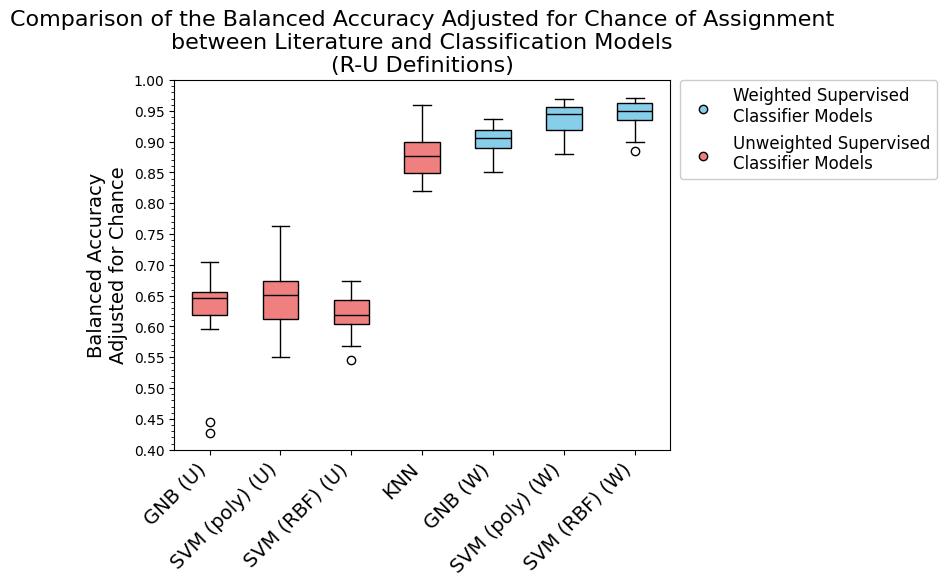

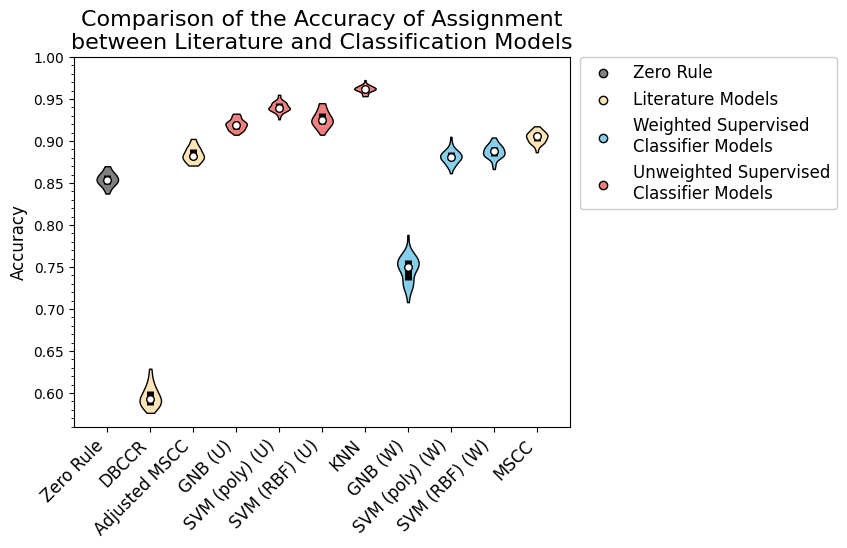

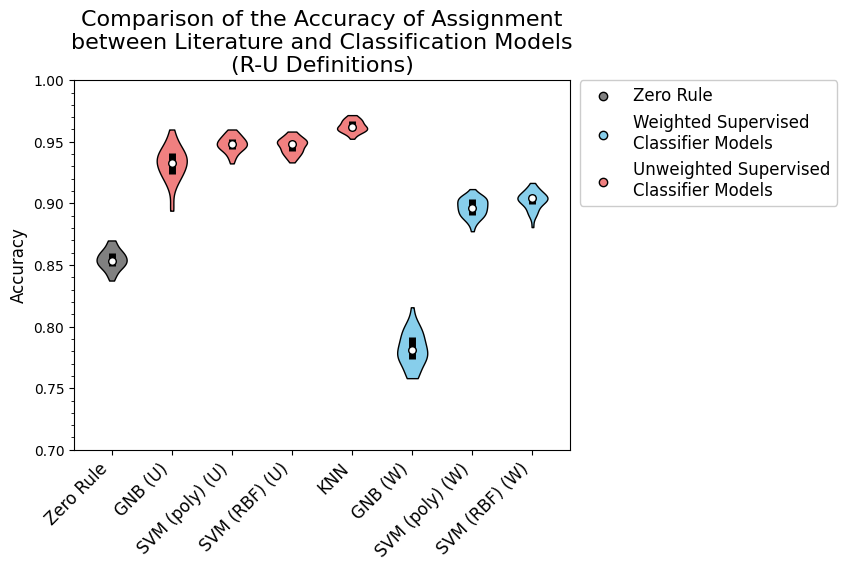

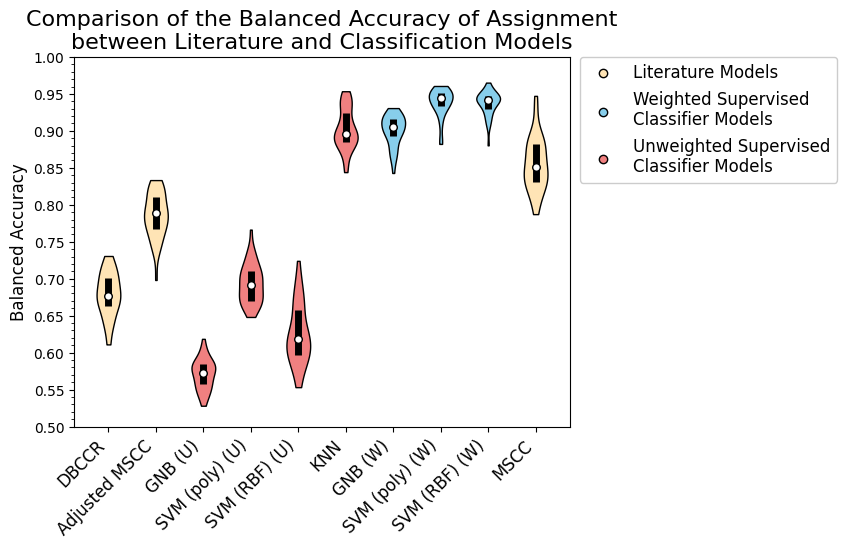

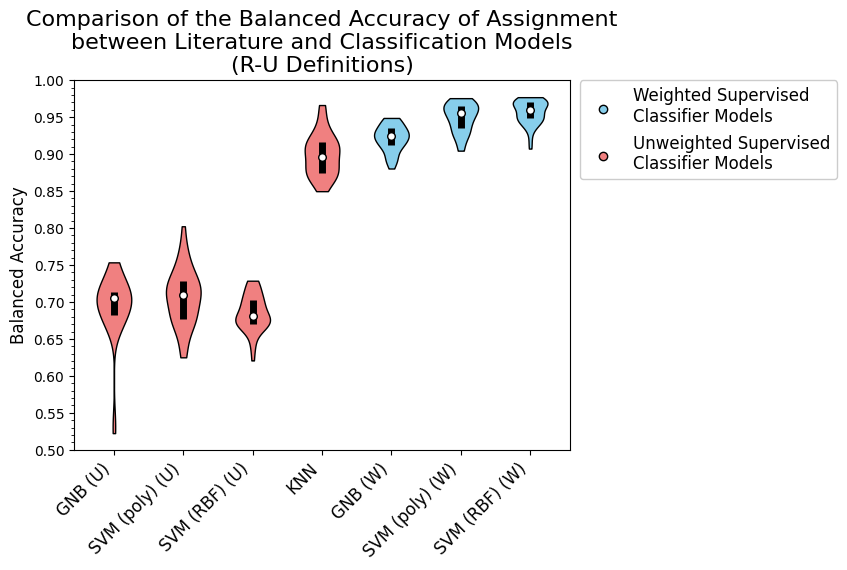

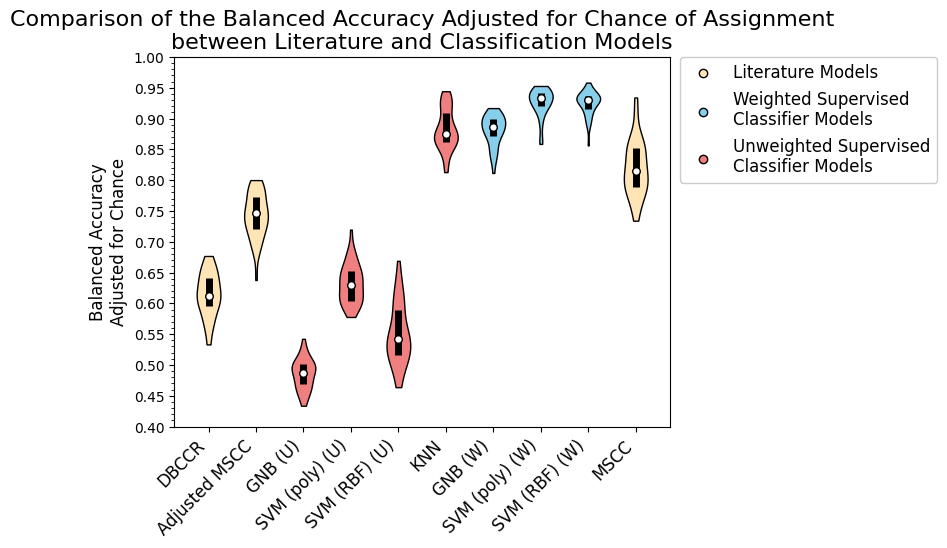

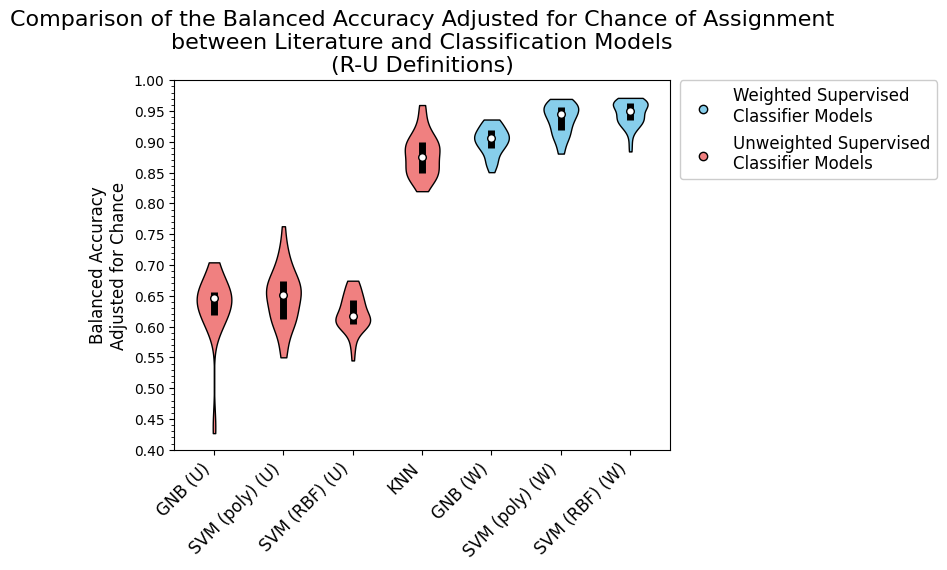

In [25]:
figsize=(10,4.8) # width, height

for plot_choice in plot_type:
    for acc_type in data_dict.keys():
        
        if acc_type == 'raw':
            ylabel = 'Accuracy'

            data_to_use = {}
            data_to_use['Zero Rule'] = zero_rule_acc
            # colours_to_use = [zero_rule_colour] + boxplot_colors
            for x in accuracies_dict: data_to_use[x] = accuracies_dict[x]
        
        elif acc_type == 'balanced':
            ylabel = 'Balanced Accuracy'
            data_to_use = balanced_accuracies_dict
            # colours_to_use = boxplot_colors
        
        elif acc_type == 'chance':
            ylabel = 'Balanced Accuracy\nAdjusted for Chance'
            data_to_use = chance_balanced_accuracies_dict
            # colours_to_use = boxplot_colors
        
        for ru_defs in [False,True]:

            if ru_defs:
                data_to_use_ru = {x.replace(' (R-U)',''):data_to_use[x] for x in data_to_use.keys() if ('R-U' in x and 'Adjusted' not in x) or x == 'Zero Rule'}
            else:
                data_to_use_ru = {x:data_to_use[x] for x in data_to_use.keys() if ('R-U' not in x or 'Adjusted' in x)}

            boxplot_colors = [model_colour(x) for x in data_to_use_ru.keys()]
            fig, ax = plot_type[plot_choice](data_to_use_ru,
                                             ylabel=ylabel,
                                             colours=boxplot_colors,
                                             )
            
            set_y_ticks(data_to_use_ru,ax,major_ticks_interval=0.05,minor_ticks_interval=0.01,rounding=2)

            if acc_type == 'raw':
                ax.scatter([], [], c=zero_rule_colour,  label='Zero Rule', edgecolors='k')

            for c in boxplot_colors_dict:
                if boxplot_colors_dict[c] in boxplot_colors:
                    ax.scatter([], [], c=boxplot_colors_dict[c], label=c, edgecolors='k')
            
            title = f'Comparison of the {ylabel.replace('\n',' ')} of Assignment\nbetween Literature and Classification Models'
            fig_path = f'{comparison_plots_output_folder}\\comparison_{plot_choice}_{acc_type}'
            if ru_defs:
                fig_path += '_rivas-ubach'
                title += '\n(R-U Definitions)'

            ax.set_title(title,fontsize=16)

            ax.legend(framealpha=1,bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0,fontsize=12)
            
            fig.savefig(f'{fig_path}.svg',dpi=600, facecolor='#fff', bbox_inches='tight')

(<Figure size 640x480 with 1 Axes>,
 <Axes: title={'center': 'Correlation Matrix of\nthe Chance Balanced Model Accuracies'}>)

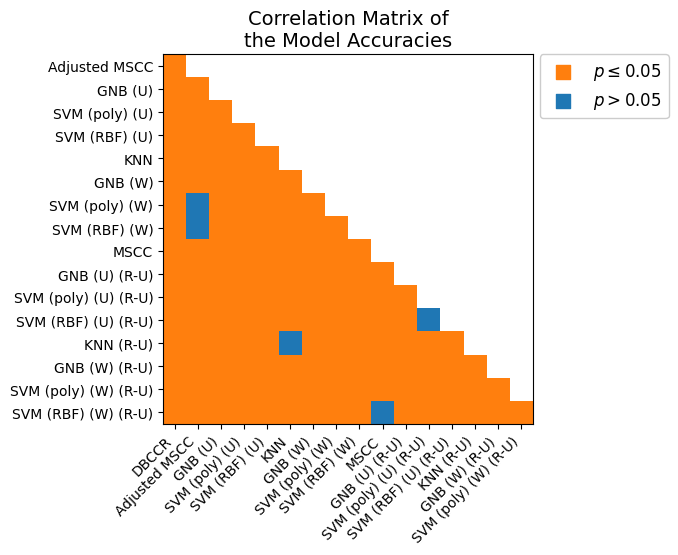

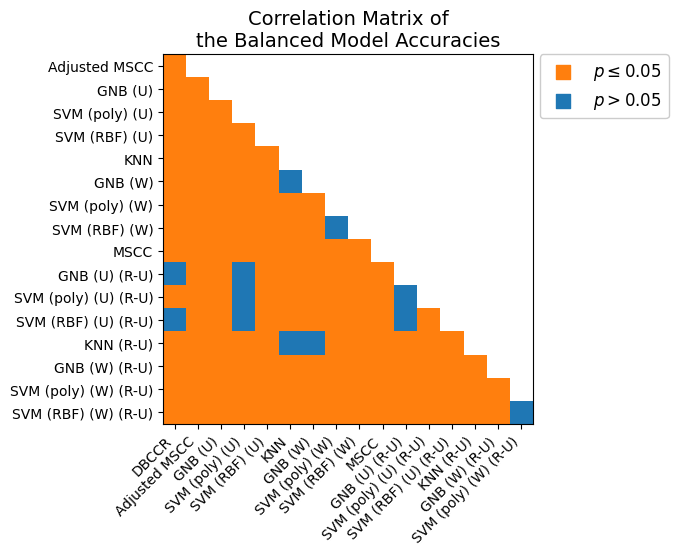

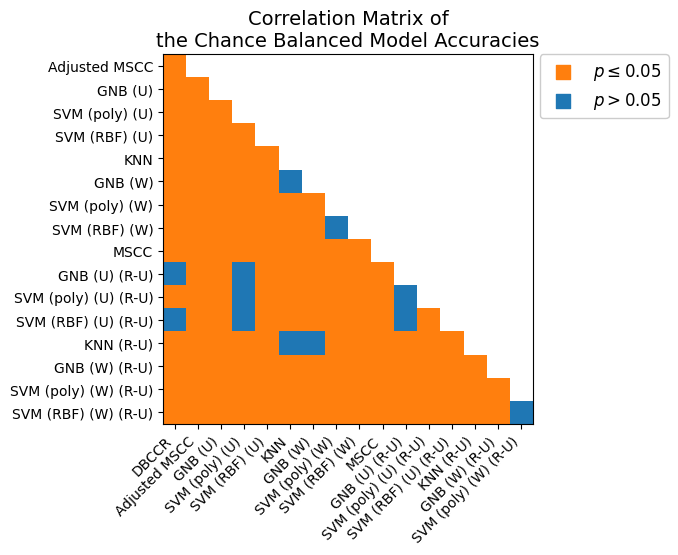

In [26]:
threshold = 0.05

correlation_matrix(accuracies_dict,threshold=threshold,
                   title='Correlation Matrix of\nthe Model Accuracies',
                   savepath=f'{comparison_plots_output_folder}\\correlation_matrix_accuracies.svg'
                   )
correlation_matrix(balanced_accuracies_dict,threshold=threshold,
                   title='Correlation Matrix of\nthe Balanced Model Accuracies',
                   savepath=f'{comparison_plots_output_folder}\\correlation_matrix_balanced_accuracies.svg'
                   )
correlation_matrix(chance_balanced_accuracies_dict,threshold=threshold,
                   title='Correlation Matrix of\nthe Chance Balanced Model Accuracies',
                   savepath=f'{comparison_plots_output_folder}\\correlation_matrix_chance_balanced_accuracies.svg'
                   )

## Now fit models by adding another category: PAHs.

In [27]:
df_with_pahs_path = 'mlacca_outputs\\csv_files\\new_vk_areas_with_pahs.csv'

In [28]:
df_with_pahs = pd.read_csv(df_with_pahs_path)

In [29]:
X_with_pahs_2d = df_with_pahs[columns_2d].to_numpy()
X_with_pahs_3d = df_with_pahs[columns_3d].to_numpy()

y_with_pahs = df_with_pahs['category'].to_numpy()
weights_with_pahs = df_with_pahs['weights'].to_numpy() if weighted else None

In [30]:
# train both classifiers with the entire dataset
knn_with_pahs_2d = mlcf.knn_pipeline(mlcf.knn_param_2d_with_PAHs).fit(X_with_pahs_2d, y_with_pahs)
gnb_with_pahs_2d = CalibratedClassifierCV(GaussianNB()).fit(X_with_pahs_2d, y_with_pahs, sample_weight=weights_with_pahs if weighted else None)
svm_poly_with_pahs_2d = CalibratedClassifierCV(SVC(kernel="poly",**mlcf.svm_poly_param_2d_with_PAHs,probability=True)).fit(X_with_pahs_2d, y_with_pahs, sample_weight=weights_with_pahs if weighted else None)
svm_rbf_with_pahs_2d = CalibratedClassifierCV(SVC(kernel="rbf", **mlcf.svm_rbf_param_2d_with_PAHs, probability=True)).fit(X_with_pahs_2d, y_with_pahs, sample_weight=weights_with_pahs if weighted else None)

In [31]:
knn_with_pahs_3d = mlcf.knn_pipeline(mlcf.knn_param_3d_with_PAHs).fit(X_with_pahs_3d, y_with_pahs)
gnb_with_pahs_3d = CalibratedClassifierCV(GaussianNB()).fit(X_with_pahs_3d, y_with_pahs, sample_weight=weights_with_pahs if weighted else None)
svm_poly_with_pahs_3d = CalibratedClassifierCV(SVC(kernel="poly",
                                                   **mlcf.svm_poly_param_3d_with_PAHs,
                                                   probability=True)).fit(X_with_pahs_3d, y_with_pahs, sample_weight=weights_with_pahs if weighted else None)
svm_rbf_with_pahs_3d = CalibratedClassifierCV(SVC(kernel="rbf",
                                                  **mlcf.svm_rbf_param_3d_with_PAHs,
                                                  probability=True)).fit(X_with_pahs_3d, y_with_pahs, sample_weight=weights_with_pahs if weighted else None)

In [32]:
persist_model_pickle(knn_with_pahs_3d,f"{models_output_folder}\\knn_with_pahs.pkl")
persist_model_pickle(gnb_with_pahs_3d,f"{models_output_folder}\\gnb_with_pahs.pkl")
persist_model_pickle(svm_poly_with_pahs_3d,f"{models_output_folder}\\svm_poly_with_pahs.pkl")
persist_model_pickle(svm_rbf_with_pahs_3d,f"{models_output_folder}\\svm_rbf_with_pahs.pkl")

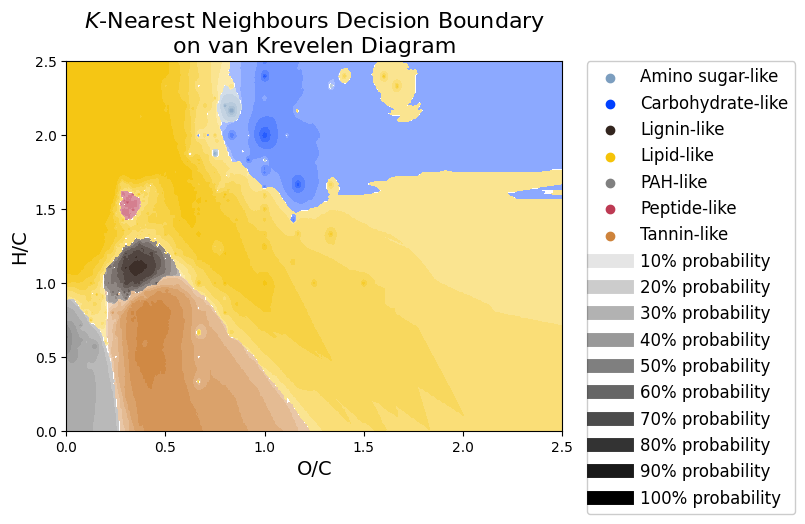

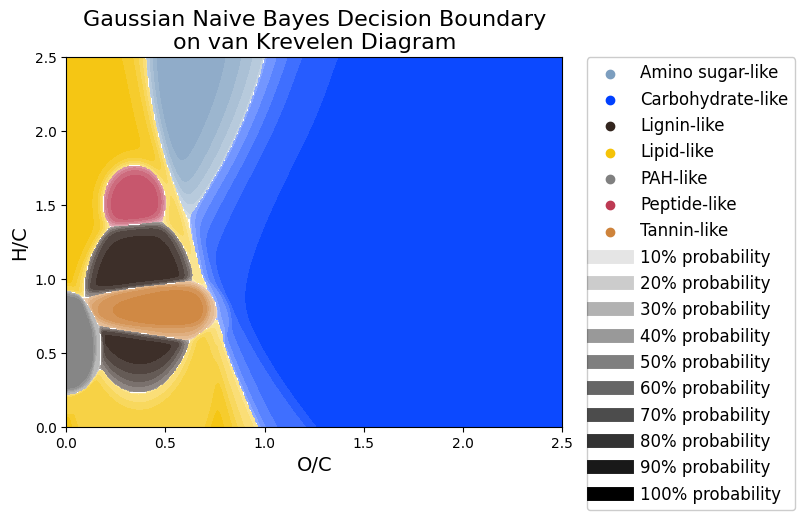

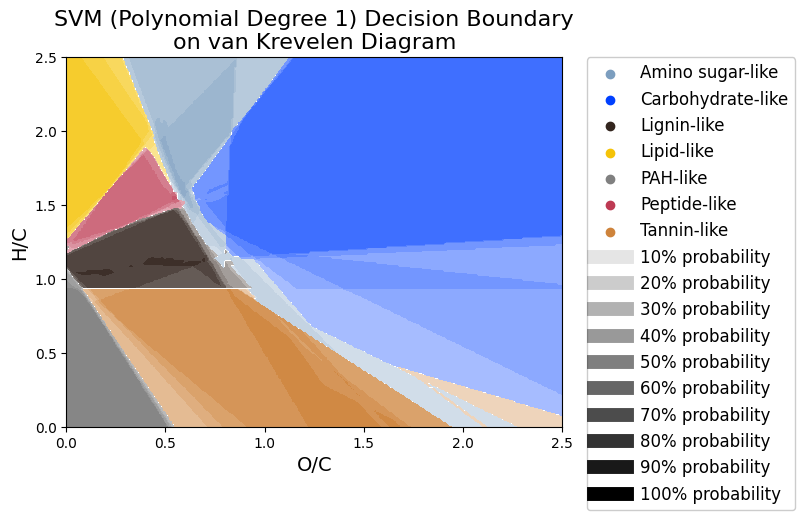

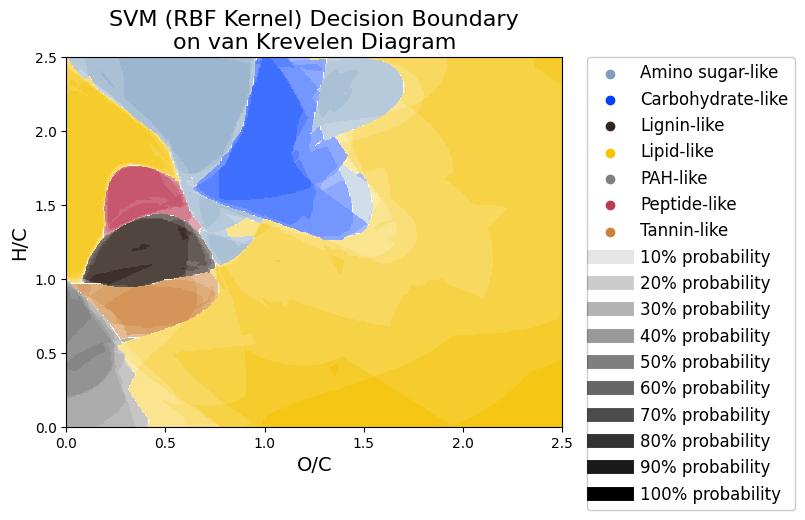

In [33]:
mlcf.draw_decision_boundary_plot(knn_with_pahs_2d,
                                X_with_pahs_2d,
                                categories=np.unique(y_with_pahs),
                                xlabel=columns_2d[0],
                                ylabel=columns_2d[1],
                                title='$K$-Nearest Neighbours Decision Boundary\non van Krevelen Diagram',
                                savepath=f'{decision_boundaries_output_folder}\\knn_vk_decision_boundary_with_pahs.svg',
                                colors_dict=mlcf.vk_region_colours
                                )

mlcf.draw_decision_boundary_plot(gnb_with_pahs_2d,
                                X_with_pahs_2d,
                                categories=np.unique(y_with_pahs),
                                xlabel=columns_2d[0],
                                ylabel=columns_2d[1],
                                title='Gaussian Naive Bayes Decision Boundary\non van Krevelen Diagram',
                                savepath=f'{decision_boundaries_output_folder}\\gnb_vk_decision_boundary_with_pahs.svg',
                                colors_dict=mlcf.vk_region_colours
                                )

mlcf.draw_decision_boundary_plot(svm_poly_with_pahs_2d,
                                X_with_pahs_2d,
                                categories=np.unique(y_with_pahs),
                                xlabel=columns_2d[0],
                                ylabel=columns_2d[1],
                                title=f'SVM (Polynomial Degree {mlcf.svm_poly_param_2d_with_PAHs["degree"]}) Decision Boundary\non van Krevelen Diagram',
                                savepath=f'{decision_boundaries_output_folder}\\svm_poly_vk_decision_boundary_with_pahs.svg',
                                colors_dict=mlcf.vk_region_colours
                                )

mlcf.draw_decision_boundary_plot(svm_rbf_with_pahs_2d,
                                X_with_pahs_2d,
                                categories=np.unique(y_with_pahs),
                                xlabel=columns_2d[0],
                                ylabel=columns_2d[1],
                                title=f'SVM (RBF Kernel) Decision Boundary\non van Krevelen Diagram',
                                savepath=f'{decision_boundaries_output_folder}\\svm_rbf_vk_decision_boundary_with_pahs.svg',
                                colors_dict=mlcf.vk_region_colours
                                )

In [34]:
DecisionBoundaryDisplay_3D(X_with_pahs_3d,
                           knn_with_pahs_3d,
                           dims=columns_3d,
                           title='K-Nearest Neighbours 3D Decision Boundary\non van Krevelen Diagram',
                           savepath=f'{decision_boundaries_output_folder}\\knn_3d_vk_decision_boundary_with_pahs.html',
                           show=False
                           )

DecisionBoundaryDisplay_3D(X_with_pahs_3d,
                           gnb_with_pahs_3d,
                           dims=columns_3d,
                           title='Gaussian Naive Bayes 3D Decision Boundary\non van Krevelen Diagram',
                           savepath=f'{decision_boundaries_output_folder}\\gnb_3d_vk_decision_boundary_with_pahs.html',
                           show=False
                           )

DecisionBoundaryDisplay_3D(X_with_pahs_3d,
                           svm_poly_with_pahs_3d,
                           dims=columns_3d,
                           title=f'Polynomial SVM 3D Decision Boundary\non van Krevelen Diagram',
                           savepath=f'{decision_boundaries_output_folder}\\svm_poly_3d_vk_decision_boundary_with_pahs.html',
                           show=False
                           )

DecisionBoundaryDisplay_3D(X_with_pahs_3d,
                           svm_rbf_with_pahs_3d,
                           dims=columns_3d,
                           title=f'RBF SVM Decision Boundary\non van Krevelen Diagram - 3D',
                           savepath=f'{decision_boundaries_output_folder}\\svm_rbf_3d_vk_decision_boundary_with_pahs.html',
                           show=False
                           )

In [35]:
clf_models_with_pahs = {
    'GNB (W)': CalibratedClassifierCV(GaussianNB()),
    'SVM (Poly) (W)': CalibratedClassifierCV(SVC(kernel="poly", **mlcf.svm_poly_param_3d_with_PAHs)),
    'SVM (RBF) (W)': CalibratedClassifierCV(SVC(kernel="rbf", **mlcf.svm_rbf_param_3d_with_PAHs)),
}

clf_models_with_pahs_unweighted = {x.replace('(W)','(U)'):clf_models_with_pahs[x] for x in clf_models_with_pahs}
clf_models_with_pahs_unweighted['KNN'] = mlcf.knn_pipeline(mlcf.knn_param_3d_with_PAHs)

models_with_pahs_list = list(clf_models_with_pahs_unweighted.keys()) + list(clf_models_with_pahs.keys())

In [36]:
accuracies_dict_with_pahs = {name: [] for name in models_with_pahs_list}
balanced_accuracies_dict_with_pahs = {name: [] for name in models_with_pahs_list}
zero_rule_with_pahs_acc = []

repeats = 40

columns = columns_3d

for n in range(repeats):
    print(f'Accuracy test iteration {n+1} of {repeats}')
    X_rdm_train, X_rdm_test, y_rdm_train, y_rdm_test, \
    weights_rdm_train, weights_rdm_test = mlcf.train_test(X_with_pahs_3d, y_with_pahs,random_state=None)

    zero_rule_class = np.unique(y_rdm_test)[np.argmax([len(np.where(y_rdm_test==cat)[0]) for cat in np.unique(y_rdm_test)])]
    zero_rule_with_pahs_acc.append(accuracy_score(y_true=y_rdm_test,
                                                  y_pred=[zero_rule_class]*len(y_rdm_test),
                                                  normalize=True))

    for model in clf_models_with_pahs:
        print(f'{n+1}/{repeats}\tTesting model: {model}')
        clf = clf_models_with_pahs[model].fit(X_rdm_train, y_rdm_train, sample_weight=weights_rdm_train if weighted else None)
        y_pred = clf.predict(X_rdm_test)

        acc = accuracy_score(y_true=y_rdm_test,
                             y_pred=y_pred,
                             normalize=True)
        accuracies_dict_with_pahs[model].append(acc)

        balanced_acc = balanced_accuracy_score(y_true=y_rdm_test,
                                               y_pred=y_pred,
                                               sample_weight=weights_rdm_test if weighted else None)
        balanced_accuracies_dict_with_pahs[model].append(balanced_acc)

        print(f'\t\taccuracy: {acc}, balanced accuracy: {balanced_acc}')
    
    for model in clf_models_with_pahs_unweighted:
        print(f'{n+1}/{repeats}\tTesting model: {model}')
        clf = clf_models_with_pahs_unweighted[model].fit(X_rdm_train, y_rdm_train)
        y_pred = clf.predict(X_rdm_test)

        acc = accuracy_score(y_true=y_rdm_test,
                             y_pred=y_pred,
                             normalize=True)
        accuracies_dict_with_pahs[model].append(acc)

        balanced_acc = balanced_accuracy_score(y_true=y_rdm_test,
                                               y_pred=y_pred,
                                               sample_weight=weights_rdm_test if weighted else None)
        balanced_accuracies_dict_with_pahs[model].append(balanced_acc)

        print(f'\t\taccuracy: {acc}, balanced accuracy: {balanced_acc}')

Accuracy test iteration 1 of 40
1/40	Testing model: GNB (W)
		accuracy: 0.7467105263157895, balanced accuracy: 0.8696489192424854
1/40	Testing model: SVM (Poly) (W)
		accuracy: 0.8675986842105263, balanced accuracy: 0.9241728730357234
1/40	Testing model: SVM (RBF) (W)
		accuracy: 0.875, balanced accuracy: 0.9259032811609778
1/40	Testing model: GNB (U)
		accuracy: 0.9103618421052632, balanced accuracy: 0.5416109967130376
1/40	Testing model: SVM (Poly) (U)
		accuracy: 0.9333881578947368, balanced accuracy: 0.7193147368216549
1/40	Testing model: SVM (RBF) (U)
		accuracy: 0.9432565789473685, balanced accuracy: 0.753202271132918
1/40	Testing model: KNN
		accuracy: 0.953125, balanced accuracy: 0.8961171073632161
Accuracy test iteration 2 of 40
2/40	Testing model: GNB (W)
		accuracy: 0.7228618421052632, balanced accuracy: 0.9085523864154295
2/40	Testing model: SVM (Poly) (W)
		accuracy: 0.8708881578947368, balanced accuracy: 0.9235413164839181
2/40	Testing model: SVM (RBF) (W)
		accuracy: 0.8

In [37]:
chance_balanced_accuracies_dict_with_pahs = {}
for key in balanced_accuracies_dict_with_pahs:
    number_of_categories = len(np.unique(y_with_pahs))

    chance = 1 / number_of_categories

    chance_balanced_accuracies_dict_with_pahs[key] = [(acc-chance)/(1 - chance) for acc in balanced_accuracies_dict_with_pahs[key] ]

comparison_with_pahs_df = pd.DataFrame({
    'model':[model.replace('$', '').replace('\\', '') for model in clf_models_with_pahs.keys()],
    'mean_accuracy':[np.mean(accuracies_dict_with_pahs[model]) for model in clf_models_with_pahs.keys()],
    'std_accuracy':[np.std(accuracies_dict_with_pahs[model]) for model in clf_models_with_pahs.keys()],
    'median_accuracy':[np.median(accuracies_dict_with_pahs[model]) for model in clf_models_with_pahs.keys()],
    'mean_balanced_accuracy':[np.mean(balanced_accuracies_dict_with_pahs[model]) for model in clf_models_with_pahs.keys()],
    'std_balanced_accuracy':[np.std(balanced_accuracies_dict_with_pahs[model]) for model in clf_models_with_pahs.keys()],
    'median_balanced_accuracy':[np.median(balanced_accuracies_dict_with_pahs[model]) for model in clf_models_with_pahs.keys()],
    'mean_chance_balanced_accuracy':[np.mean(chance_balanced_accuracies_dict_with_pahs[model]) for model in clf_models_with_pahs.keys()],
    'std_chance_balanced_accuracy':[np.std(chance_balanced_accuracies_dict_with_pahs[model]) for model in clf_models_with_pahs.keys()],
    'median_chance_balanced_accuracy':[np.median(chance_balanced_accuracies_dict_with_pahs[model]) for model in clf_models_with_pahs.keys()],
})

comparison_with_pahs_df.to_csv('mlacca_outputs\\csv_files\\model_performance_comparison_with_pahs.csv', index=False)

In [38]:
boxplot_with_pahs_colors = []

for model in models_with_pahs_list:
    if model in clf_models_with_pahs:
        boxplot_with_pahs_colors.append(boxplot_colors_dict['Weighted Supervised\nClassifier Models'])
    elif model in clf_models_with_pahs_unweighted:
        boxplot_with_pahs_colors.append(boxplot_colors_dict['Unweighted Supervised\nClassifier Models'])
zero_rule_colour = 'grey'

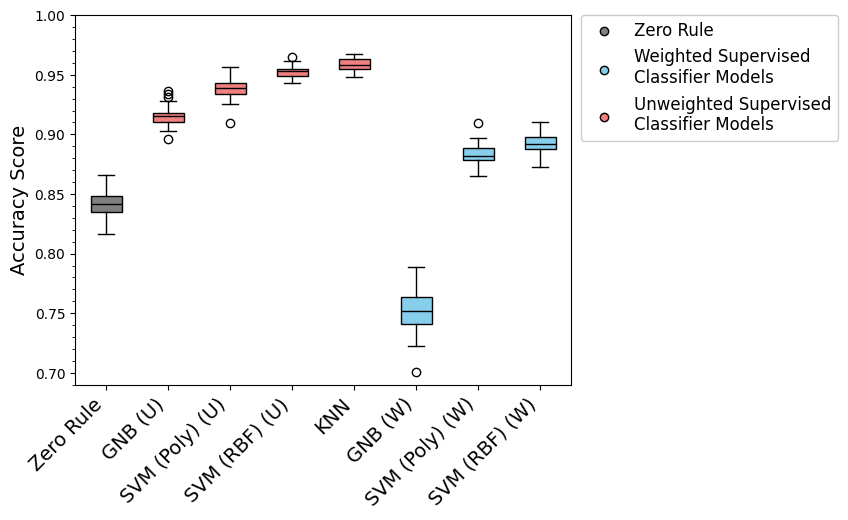

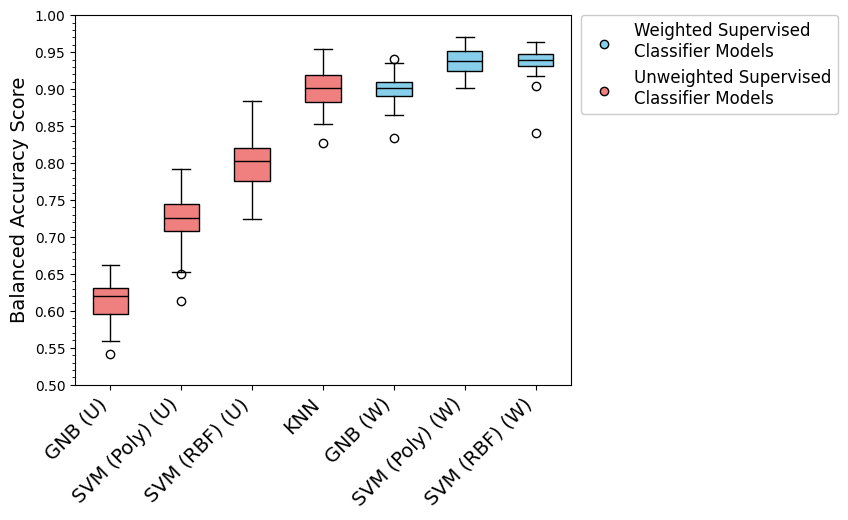

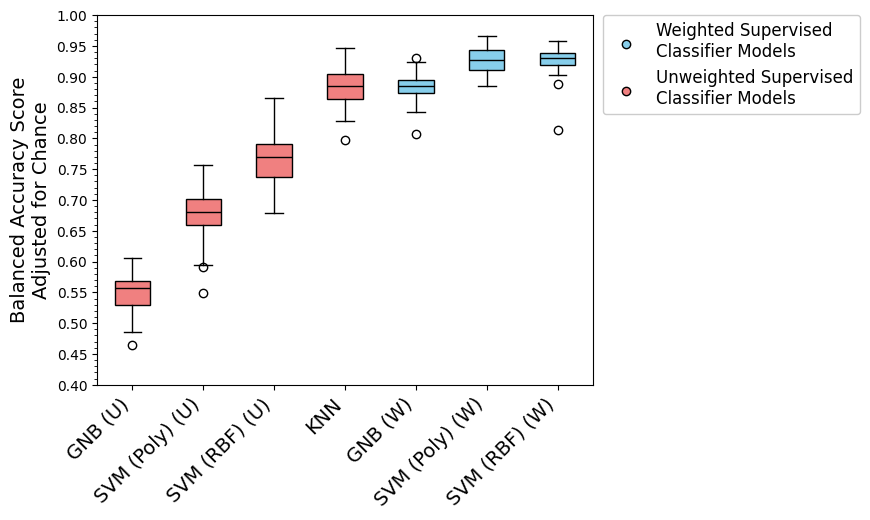

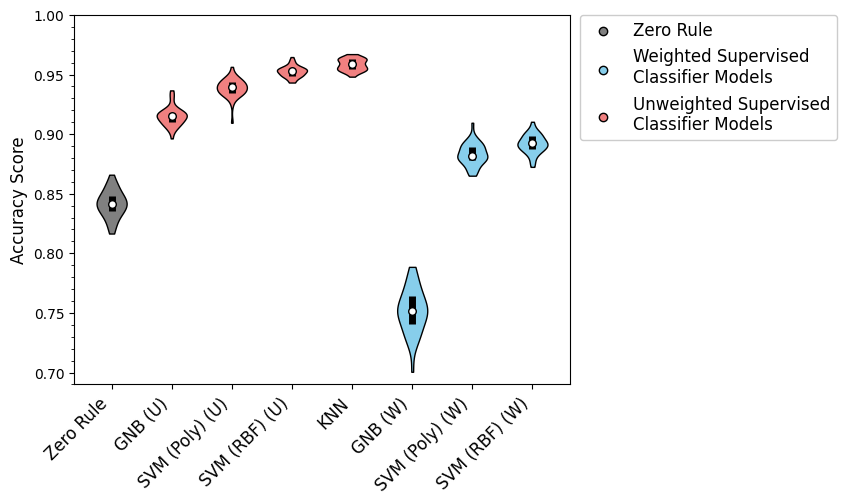

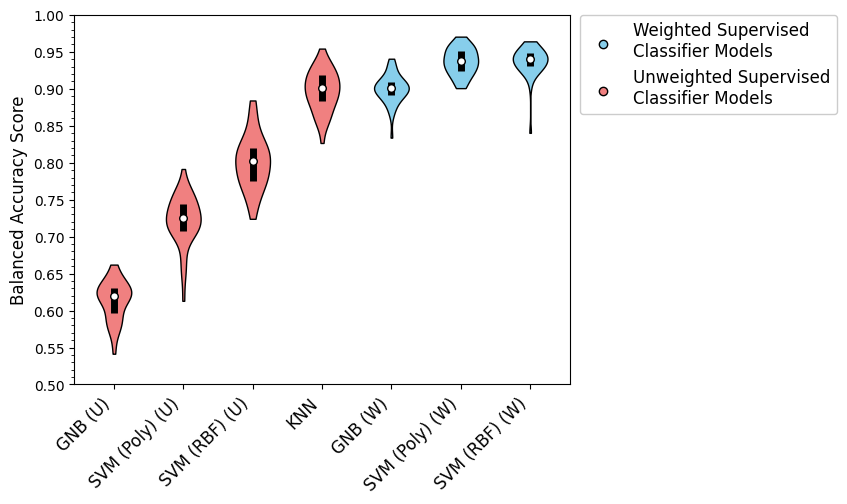

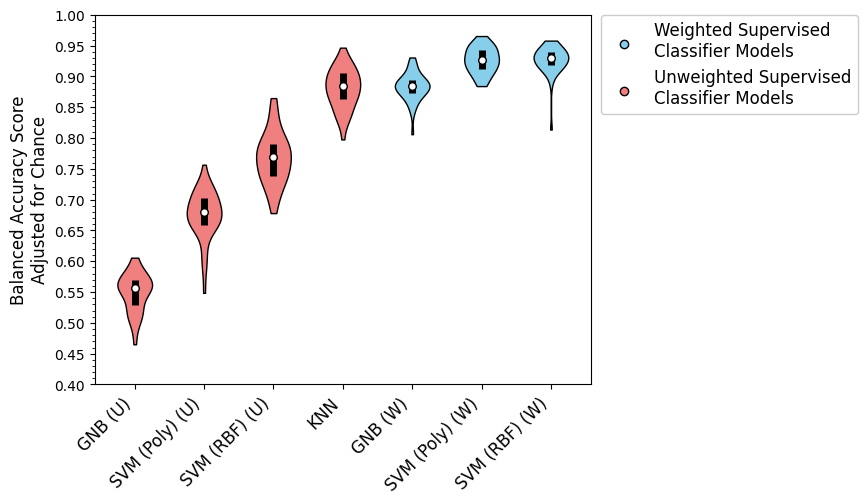

In [39]:
data_dict_with_pahs = {'raw':accuracies_dict_with_pahs,
                       'balanced':balanced_accuracies_dict_with_pahs,
                       'chance':chance_balanced_accuracies_dict_with_pahs}

figsize=None#(10,4.8)

for plot_choice in plot_type:
    for acc_type in data_dict_with_pahs.keys():
        if acc_type == 'raw':
            ylabel = 'Accuracy Score'

            data_to_use = {}
            data_to_use['Zero Rule'] = zero_rule_with_pahs_acc
            colours_to_use = [zero_rule_colour] + boxplot_with_pahs_colors
            for x in accuracies_dict_with_pahs: data_to_use[x] = accuracies_dict_with_pahs[x]
        
        elif acc_type == 'balanced':
            ylabel = 'Balanced Accuracy Score'
            data_to_use = balanced_accuracies_dict_with_pahs
            colours_to_use = boxplot_with_pahs_colors
        
        elif acc_type == 'chance':
            ylabel = 'Balanced Accuracy Score\nAdjusted for Chance'
            data_to_use = chance_balanced_accuracies_dict_with_pahs
            colours_to_use = boxplot_with_pahs_colors

        fig, ax = plot_type[plot_choice](data_to_use,
                                         ylabel=ylabel,
                                         colours=colours_to_use,
                                         figsize=figsize,
                                         savepath=f'{comparison_plots_output_folder}\\comparison_with_pahs_{plot_choice}_{acc_type}.svg',
                                         )
        set_y_ticks(data_to_use,ax,major_ticks_interval=0.05,
                    minor_ticks_interval=0.01,rounding=2)
        
        if acc_type == 'raw':
            ax.scatter([], [], c=zero_rule_colour,  label='Zero Rule', edgecolors='k')

        for c in boxplot_colors_dict:
            if boxplot_colors_dict[c] in boxplot_with_pahs_colors:
                ax.scatter([], [], c=boxplot_colors_dict[c], label=c, edgecolors='k')

        ax.legend(framealpha=1,bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0,fontsize=12)
        fig.savefig(f'{comparison_plots_output_folder}\\comparison_with_pahs_{plot_choice}_{acc_type}.svg',
                    dpi=600, facecolor='#fff', bbox_inches='tight')

(<Figure size 640x480 with 1 Axes>,
 <Axes: title={'center': 'Correlation Matrix of\nthe Chance Balanced Model Accuracies Including PAHs'}>)

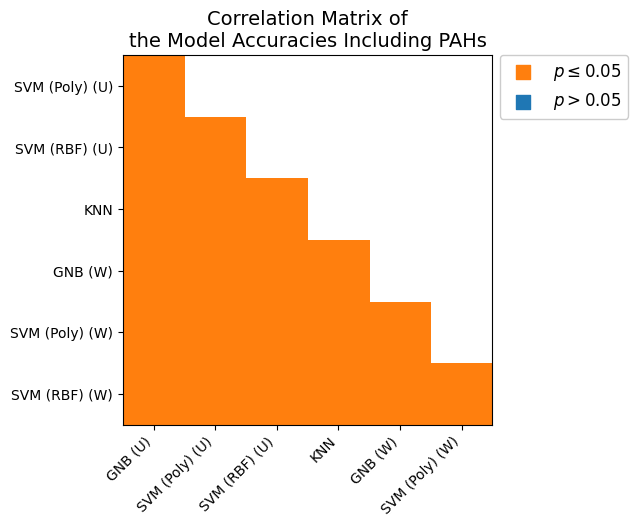

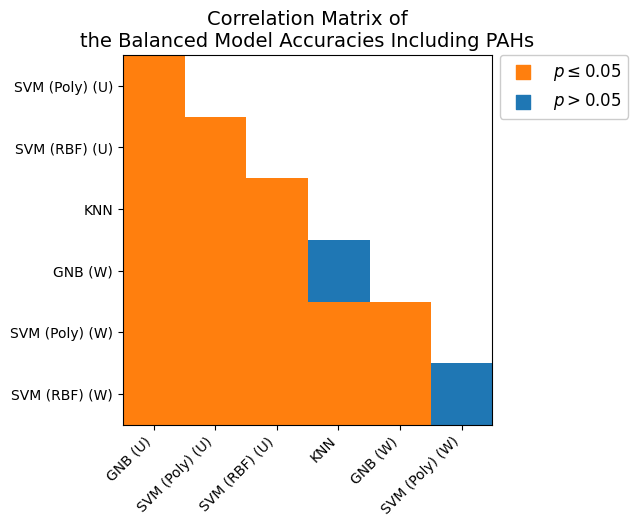

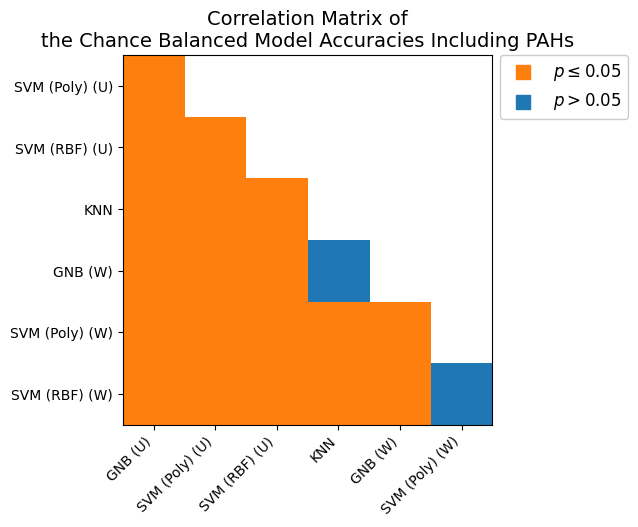

In [40]:
threshold = 0.05

correlation_matrix(accuracies_dict_with_pahs,threshold=threshold,
                   title='Correlation Matrix of\nthe Model Accuracies Including PAHs',
                   savepath=f'{comparison_plots_output_folder}\\correlation_matrix_accuracies_with_pahs.svg'
                   )
correlation_matrix(balanced_accuracies_dict_with_pahs,threshold=threshold,
                   title='Correlation Matrix of\nthe Balanced Model Accuracies Including PAHs',
                   savepath=f'{comparison_plots_output_folder}\\correlation_matrix_balanced_accuracies_with_pahs.svg'
                   )
correlation_matrix(chance_balanced_accuracies_dict_with_pahs,threshold=threshold,
                   title='Correlation Matrix of\nthe Chance Balanced Model Accuracies Including PAHs',
                   savepath=f'{comparison_plots_output_folder}\\correlation_matrix_chance_balanced_accuracies_with_pahs.svg'
                   )